In [3]:
import scanpy as sc
import pandas as pd
import glob
import os
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

In [4]:
tf.keras.backend.clear_session()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
tcga_features = pd.read_csv("/data/kumarr17/common_features_ver3.txt", header=None)
cyt_features = pd.read_csv("/data/kumarr17/common_cyt_nichenet_gulden_tcga.txt", header=None)
tcga_features_list=list(tcga_features[0])
cyt_features_list=list(cyt_features[0])

In [6]:
df_spatial=pd.read_csv("/data/kumarr17/Spatial_transcriptomics_data/ST_data_ov.csv",index_col='Unnamed: 0')

In [7]:
# ============================================================
# SETTINGS
# ============================================================

context = "TCGA"

# Already-common input features
feature_list = tcga_features_list

# Cytokines to train/predict
cyt_tmp = cyt_features_list

pred_df_list = []


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = "/data/kumarr17/fixed_feature_cyt_result/ST_result/"

# Create directory if it does not already exist
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(
    output_dir,
    "pred_cyt_on_spatial_spot_fixed_features_ov.csv"
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)


# ============================================================
# LOAD TCGA
# ============================================================

df_gene_exp_tcga_bulk = pd.read_csv(
    f"/data/kumarr17/merged_sample_mtx/{context}_Merged_mRNA_Expression.tsv",
    index_col="Unnamed: 0"
)


# ============================================================
# TCGA INPUT MATRIX
# ============================================================

X_tcga_df = df_gene_exp_tcga_bulk[
    feature_list
].copy()

print("Number of input features:", len(feature_list))
print("Number of cytokines:", len(cyt_tmp))
print("Number of TCGA samples:", len(X_tcga_df))


# ============================================================
# ROW-WISE Z-SCORE TCGA
# ============================================================

row_mean_tcga = X_tcga_df.mean(axis=1)

row_std_tcga = (
    X_tcga_df
    .std(axis=1)
    .replace(0, 1)
)

X_tcga_z = (
    X_tcga_df
    .sub(row_mean_tcga, axis=0)
    .div(row_std_tcga, axis=0)
)

X_tcga_z = X_tcga_z.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

X_tcga = X_tcga_z.to_numpy(
    dtype=np.float32
)


# ============================================================
# FIT STANDARD SCALER ON TCGA
# ============================================================

scaler = StandardScaler()

X_tcga_scaled = scaler.fit_transform(
    X_tcga
).astype(np.float32)


# ============================================================
# SPATIAL INPUT MATRIX
# EXACT SAME FEATURES AND ORDER
# ============================================================

X_spatial_df = df_spatial[
    feature_list
].copy()

print("Number of spatial spots:", len(X_spatial_df))


# ============================================================
# ROW-WISE Z-SCORE SPATIAL
# ============================================================

row_mean_spatial = X_spatial_df.mean(axis=1)

row_std_spatial = (
    X_spatial_df
    .std(axis=1)
    .replace(0, 1)
)

X_spatial_z = (
    X_spatial_df
    .sub(row_mean_spatial, axis=0)
    .div(row_std_spatial, axis=0)
)

X_spatial_z = X_spatial_z.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

X_spatial = X_spatial_z.to_numpy(
    dtype=np.float32
)


# ============================================================
# APPLY TCGA-FITTED SCALER TO SPATIAL
# ============================================================

X_spatial_scaled = scaler.transform(
    X_spatial
).astype(np.float32)


# ============================================================
# MODEL BUILDER
# ============================================================

def build_fcnn(input_dim):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model


# ============================================================
# DEFINE SPOT INDEX ONCE
# ============================================================

if "spot_id" in df_spatial.columns:

    spot_index = df_spatial["spot_id"].tolist()

else:

    spot_index = df_spatial.index


# ============================================================
# TRAIN ON TCGA AND PREDICT SPATIAL
# ============================================================

for yy, cytokine_to_check in enumerate(cyt_tmp):

    print(
        f"Training {yy + 1}/{len(cyt_tmp)}: "
        f"{cytokine_to_check}"
    )


    # --------------------------------------------------------
    # TCGA TARGET
    # --------------------------------------------------------

    y_tcga = df_gene_exp_tcga_bulk[
        [cytokine_to_check]
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # CLEAR PREVIOUS MODEL
    # --------------------------------------------------------

    tf.keras.backend.clear_session()


    # --------------------------------------------------------
    # BUILD NEW CYTOKINE-SPECIFIC MODEL
    # --------------------------------------------------------

    final_model = build_fcnn(
        X_tcga_scaled.shape[1]
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    early_stop = keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=5,
        restore_best_weights=True
    )


    # --------------------------------------------------------
    # TRAIN ON ALL TCGA SAMPLES
    # --------------------------------------------------------

    final_model.fit(
        X_tcga_scaled,
        y_tcga,
        epochs=50,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop]
    )


    # --------------------------------------------------------
    # PREDICT ON ALL SPATIAL SPOTS
    # --------------------------------------------------------

    y_pred_spatial = final_model.predict(
        X_spatial_scaled,
        verbose=0
    ).ravel()


    # --------------------------------------------------------
    # STORE CYTOKINE PREDICTIONS
    # --------------------------------------------------------

    df_pred_score = pd.DataFrame(
        y_pred_spatial,
        index=spot_index,
        columns=[cytokine_to_check]
    )

    pred_df_list.append(
        df_pred_score
    )


# ============================================================
# COMBINE ALL CYTOKINES
# ============================================================

pred_cyt_on_spatial_spot = pd.concat(
    pred_df_list,
    axis=1
)


# ============================================================
# SAVE
# ============================================================

pred_cyt_on_spatial_spot.to_csv(
    output_file
)


# ============================================================
# SUMMARY
# ============================================================

print("\n============================================")
print("FINISHED")
print("============================================")

print(
    "Final prediction matrix shape:",
    pred_cyt_on_spatial_spot.shape
)

print(
    "Number of spots:",
    pred_cyt_on_spatial_spot.shape[0]
)

print(
    "Number of predicted cytokines:",
    pred_cyt_on_spatial_spot.shape[1]
)

print(
    "Saved to:",
    output_file
)

print(
    pred_cyt_on_spatial_spot.head()
)

Number of input features: 6075
Number of cytokines: 645
Number of TCGA samples: 9491
Number of spatial spots: 5005
Training 1/645: INHA


2026-09-15 13:43:12.865860: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-09-15 13:43:12.865911: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-09-15 13:43:12.865931: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (cn0013): /proc/driver/nvidia/version does not exist
2026-09-15 13:43:12.866208: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training 2/645: FGF7
Training 3/645: BMP6
Training 4/645: IL25
Training 5/645: CCL21
Training 6/645: LIPH
Training 7/645: SFTPA1
Training 8/645: FGF23
Training 9/645: ADCYAP1
Training 10/645: MIA
Training 11/645: VCAM1
Training 12/645: BMP15
Training 13/645: ARF1
Training 14/645: ANGPTL4
Training 15/645: PODXL2
Training 16/645: IL18
Training 17/645: FGF21
Training 18/645: COL4A5
Training 19/645: FAT4
Training 20/645: MADCAM1
Training 21/645: RGMA
Training 22/645: PDGFC
Training 23/645: PLAT
Training 24/645: ADAM28
Training 25/645: IL24
Training 26/645: DEFB1
Training 27/645: FN1
Training 28/645: PNOC
Training 29/645: CAMP
Training 30/645: CSHL1
Training 31/645: OLFM2
Training 32/645: A2M
Training 33/645: CEL
Training 34/645: GRP
Training 35/645: MUC7
Training 36/645: MLN
Training 37/645: IL1F10
Training 38/645: CCL20
Training 39/645: PMCH
Training 40/645: SPON2
Training 41/645: CXCL11
Training 42/645: GDF6
Training 43/645: VWF
Training 44/645: RSPO3
Training 45/645: SERPINE2
Training 4

#### Importing the prediction in Ovarian spot transcriptomics and potting the AUROC

In [8]:
df_spatial_pred=pd.read_csv("/data/kumarr17/fixed_feature_cyt_result/ST_result/pred_cyt_on_spatial_spot_fixed_features_ov.csv")
df_spatial_pred['sample'] = df_spatial_pred['Unnamed: 0'].str.split('_').str[0]
response_map = {
    "GSM5708485": "Responder",
    "GSM5708486": "Responder",
    "GSM5708487": "Responder",
    "GSM5708488": "Responder",
    "GSM5708489": "Responder",
    "GSM5708490": "Responder",

    "GSM5708491": "NonResponder",
    "GSM5708492": "NonResponder",
    "GSM5708493": "NonResponder",
    "GSM5708494": "NonResponder",
    "GSM5708495": "NonResponder",
    "GSM5708496": "NonResponder"
}

df_spatial_pred["response"] = df_spatial_pred["sample"].map(response_map)
df_spatial_pred_v1=df_spatial_pred.set_index('Unnamed: 0')

In [9]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# df = your dataframe shown above
# index = spot/barcode
# columns include: sample, response, predicted gene/cytokine scores

df = df_spatial_pred_v1.copy()

# ----------------------------
# define X, y, groups
# ----------------------------
meta_cols = ["sample", "response"]

feature_cols = [
    c for c in df.columns
    if c not in meta_cols
]

X = df[feature_cols].copy()

y = df["response"].map({
    "Responder": 1,
    "NonResponder": 0
})

groups = df["sample"].values

# remove missing values
valid = y.notna() & X.notna().all(axis=1)

X = X.loc[valid]
y = y.loc[valid]
groups = groups[valid]
spot_ids = X.index

# ----------------------------
# Leave-one-sample-out CV
# ----------------------------
logo = LeaveOneGroupOut()

all_results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):

    test_sample = np.unique(groups[test_idx])[0]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear"
        )
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])

    prob_responder = model.predict_proba(X.iloc[test_idx])[:, 1]
    pred_label = (prob_responder >= 0.5).astype(int)

    fold_df = pd.DataFrame({
        "spot_id": spot_ids[test_idx],
        "sample": groups[test_idx],
        "true_label": y.iloc[test_idx].values,
        "pred_prob_responder": prob_responder,
        "pred_label": pred_label
    })

    all_results.append(fold_df)

spot_pred_df = pd.concat(all_results, axis=0)

spot_pred_df["true_response"] = spot_pred_df["true_label"].map({
    1: "Responder",
    0: "NonResponder"
})

spot_pred_df["pred_response"] = spot_pred_df["pred_label"].map({
    1: "Responder",
    0: "NonResponder"
})

spot_pred_df.head()

,spot_id,sample,true_label,pred_prob_responder,pred_label,true_response,pred_response
0,GSM5708485_AAACACCAATAACTGC-1,GSM5708485,1,1.000000,1,Responder,Responder
1,GSM5708485_AAACTGCTGGCTCCAA-1,GSM5708485,1,0.000050,0,Responder,NonResponder
2,GSM5708485_AAACTTGCAAACGTAT-1,GSM5708485,1,0.999970,1,Responder,Responder
3,GSM5708485_AAAGGCTCTCGCGCCG-1,GSM5708485,1,0.853730,1,Responder,Responder
4,GSM5708485_AAATACCTATAAGCAT-1,GSM5708485,1,0.995759,1,Responder,Responder


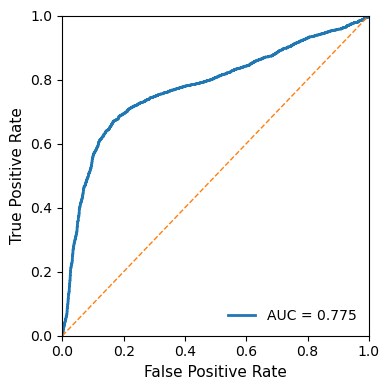

In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# True labels and predicted probabilities
y_true = spot_pred_df["true_label"]
y_score = spot_pred_df["pred_prob_responder"]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(4, 4))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)

# Remove title if this is going into a multi-panel manuscript figure
# plt.title("ROC Curve (Spot-level)", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

plt.xlim(0, 1)
plt.ylim(0, 1)

# No grid for cleaner manuscript appearance
plt.grid(False)

plt.tight_layout()

# Save manuscript-quality vector SVG
#plt.savefig(
#    "/data/kumarr17/cytokine_figure_directory/OV_spot_level_ROC_curve.svg",
#    format="svg",
#    bbox_inches="tight"
#)

#plt.show()

In [11]:
sample_pred_df = (
    spot_pred_df
    .groupby("sample")
    .agg(
        true_label=("true_label", "first"),
        pred_prob_mean=("pred_prob_responder", "mean"),
        pred_prob_median=("pred_prob_responder", "median"),
        n_spots=("spot_id", "count")
    )
    .reset_index()
)

sample_auc_mean = roc_auc_score(
    sample_pred_df["true_label"],
    sample_pred_df["pred_prob_mean"]
)

sample_auc_median = roc_auc_score(
    sample_pred_df["true_label"],
    sample_pred_df["pred_prob_median"]
)

print("Sample-level AUC using mean spot probability:", sample_auc_mean)
print("Sample-level AUC using median spot probability:", sample_auc_median)

sample_pred_df

Sample-level AUC using mean spot probability: 0.8333333333333334
Sample-level AUC using median spot probability: 0.888888888888889


,sample,true_label,pred_prob_mean,pred_prob_median,n_spots
0,GSM5708485,1,0.877937,0.999894,439
1,GSM5708486,1,0.667701,0.965088,382
2,GSM5708487,1,0.798273,0.995311,173
3,GSM5708488,1,0.763103,0.987546,356
4,GSM5708489,1,0.924488,0.999921,598
5,GSM5708490,1,0.044928,0.001878,285
6,GSM5708491,0,0.565813,0.658868,291
7,GSM5708492,0,0.418356,0.057113,355
8,GSM5708493,0,0.243801,0.082959,500
9,GSM5708494,0,0.243349,0.014816,1021


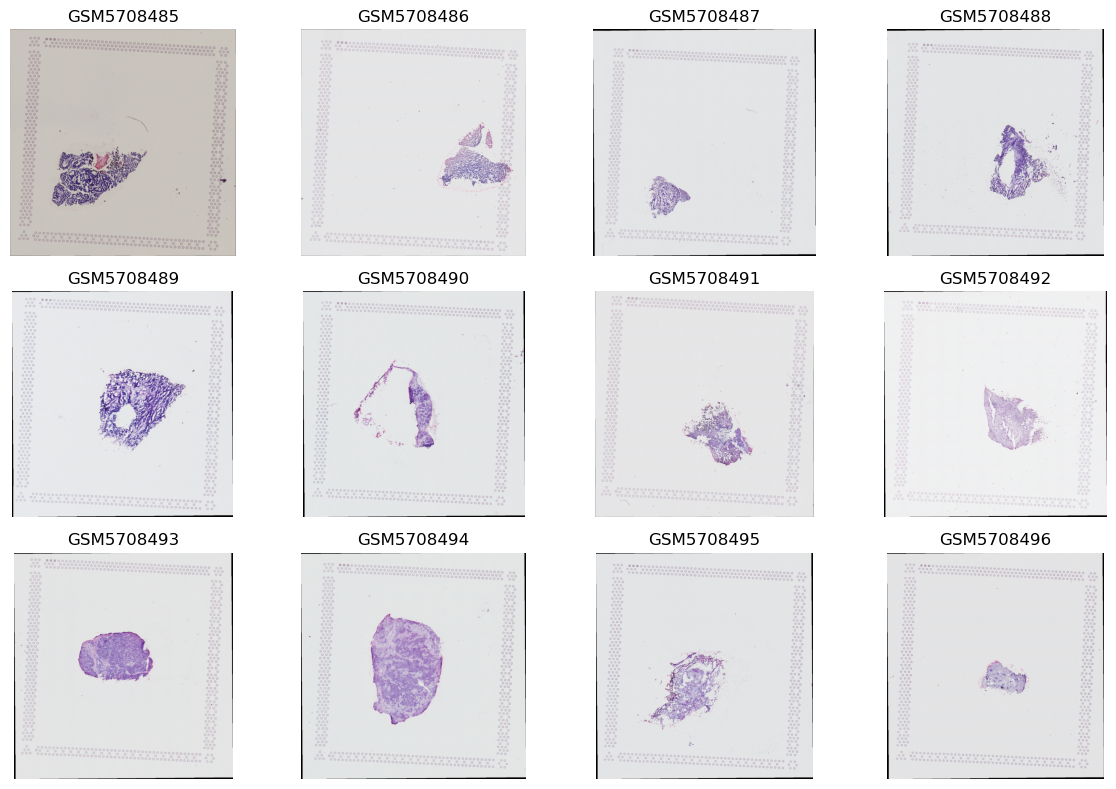

In [12]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base_dir = "/data/kumarr17/Spatial_transcriptomics_data/GSE189843/GSE189843/suppl"

files = [
    "GSM5708485_II21472_tissue_hires_image.png",
    "GSM5708486_II21473_tissue_hires_image.png",
    "GSM5708487_II21474_tissue_hires_image.png",
    "GSM5708488_II21475_tissue_hires_image.png",
    "GSM5708489_II21476_tissue_hires_image.png",
    "GSM5708490_II21477_tissue_hires_image.png",
    "GSM5708491_II21478_tissue_hires_image.png",
    "GSM5708492_II21479_tissue_hires_image.png",
    "GSM5708493_II21480_tissue_hires_image.png",
    "GSM5708494_II21481_tissue_hires_image.png",
    "GSM5708495_II21482_tissue_hires_image.png",
    "GSM5708496_II21483_tissue_hires_image.png"
]

cols = 4
rows = (len(files) + cols - 1) // cols

plt.figure(figsize=(12, 8))

for i, f in enumerate(files):
    img_path = os.path.join(base_dir, f)
    img = Image.open(img_path).convert("RGB")

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(f.split("_")[0])  # GSM ID
    plt.axis("off")

plt.tight_layout()
plt.show()